In [ ]:
# LIBRARIES IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# DATA LOAD
import pandas as pd
df = pd.read_csv("flight_300.csv")
df.head()

,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
0,3,4,AS,19930,AS,N365VA,1027,12892,1289208,LAX,...,SFO,935.0,0.0,0900-0959,1107.0,0.0,0.0,0.0,337.0,NaN
1,2,3,HA,19690,HA,N491HA,397,12758,1275804,KOA,...,HNL,1817.0,0.0,1800-1859,1903.0,0.0,0.0,0.0,163.0,NaN
2,14,1,DL,19790,DL,N920AT,2466,11433,1143302,DTW,...,MSY,843.0,0.0,0800-0859,1023.0,0.0,0.0,0.0,926.0,NaN
3,7,1,9E,20363,9E,N676CA,5235,12953,1295304,LGA,...,CVG,645.0,0.0,0600-0659,840.0,0.0,0.0,0.0,585.0,NaN
4,9,3,OO,20304,OO,N764SK,2958,14107,1410702,PHX,...,FLG,1759.0,0.0,1800-1859,1849.0,0.0,0.0,0.0,119.0,NaN


In [6]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DAY_OF_MONTH           300 non-null    int64  
 1   DAY_OF_WEEK            300 non-null    int64  
 2   OP_UNIQUE_CARRIER      300 non-null    object 
 3   OP_CARRIER_AIRLINE_ID  300 non-null    int64  
 4   OP_CARRIER             300 non-null    object 
 5   TAIL_NUM               299 non-null    object 
 6   OP_CARRIER_FL_NUM      300 non-null    int64  
 7   ORIGIN_AIRPORT_ID      300 non-null    int64  
 8   ORIGIN_AIRPORT_SEQ_ID  300 non-null    int64  
 9   ORIGIN                 300 non-null    object 
 10  DEST_AIRPORT_ID        300 non-null    int64  
 11  DEST_AIRPORT_SEQ_ID    300 non-null    int64  
 12  DEST                   300 non-null    object 
 13  DEP_TIME               287 non-null    float64
 14  DEP_DEL15              287 non-null    float64
 15  DEP_TI

DAY_OF_MONTH               0
DAY_OF_WEEK                0
OP_UNIQUE_CARRIER          0
OP_CARRIER_AIRLINE_ID      0
OP_CARRIER                 0
TAIL_NUM                   1
OP_CARRIER_FL_NUM          0
ORIGIN_AIRPORT_ID          0
ORIGIN_AIRPORT_SEQ_ID      0
ORIGIN                     0
DEST_AIRPORT_ID            0
DEST_AIRPORT_SEQ_ID        0
DEST                       0
DEP_TIME                  13
DEP_DEL15                 13
DEP_TIME_BLK               0
ARR_TIME                  14
ARR_DEL15                 14
CANCELLED                  0
DIVERTED                   0
DISTANCE                   0
Unnamed: 21              300
dtype: int64

In [8]:
# DATA CLEANING
df.fillna(0, inplace=True)

In [14]:
# Delay status column
df['Departure_Delayed'] = df['DEP_DEL15']
df['Arrival_Delayed'] = df['ARR_DEL15']

print(df[['DEP_DEL15', 'Departure_Delayed', 'ARR_DEL15', 'Arrival_Delayed']].head())

   DEP_DEL15  Departure_Delayed  ARR_DEL15  Arrival_Delayed
0        0.0                0.0        0.0              0.0
1        0.0                0.0        0.0              0.0
2        0.0                0.0        0.0              0.0
3        0.0                0.0        0.0              0.0
4        0.0                0.0        0.0              0.0


In [15]:
# Overall delay flag
df['Any_Delay'] = ((df['DEP_DEL15'] == 1) | (df['ARR_DEL15'] == 1)).astype(int)
print("Total delayed flights:", df['Any_Delay'].sum())
print("Percentage delayed:", df['Any_Delay'].mean()*100, "%")

Total delayed flights: 63
Percentage delayed: 21.0 %


In [16]:
# Cancellation clean
df['CANCELLED'] = df['CANCELLED'].map({0: "No", 1: "Yes"})

print(df['CANCELLED'].head())

print(df[['CANCELLED']].head())

print(df['CANCELLED'].value_counts())


0    No
1    No
2    No
3    No
4    No
Name: CANCELLED, dtype: object
  CANCELLED
0        No
1        No
2        No
3        No
4        No
CANCELLED
No     287
Yes     13
Name: count, dtype: int64


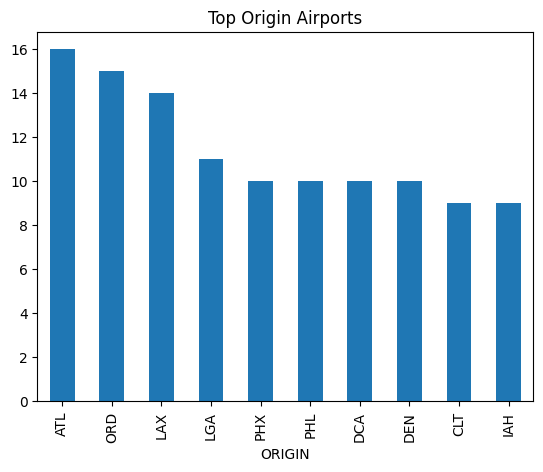

In [22]:
# Top Airports
import matplotlib.pyplot as plt
df['ORIGIN'].value_counts().head(10).plot(kind='bar')

plt.title("Top Origin Airports")
plt.show()

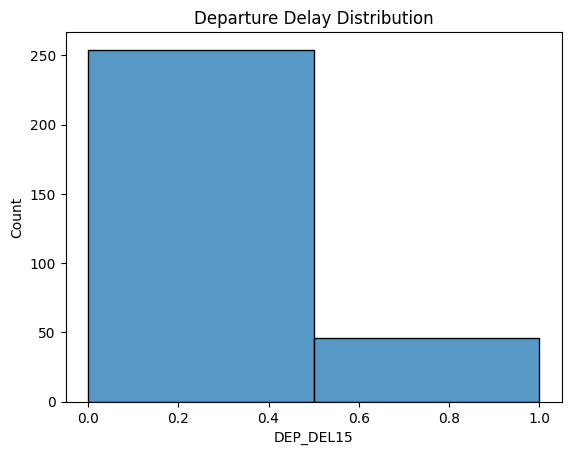

In [21]:
# Delay Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['DEP_DEL15'], bins=2)
plt.title("Departure Delay Distribution")
plt.show()

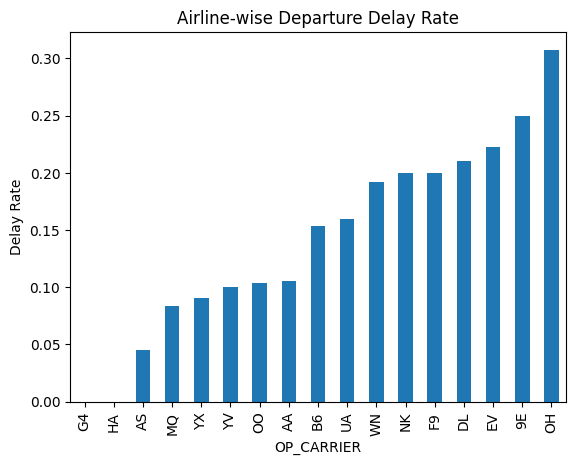

In [23]:
# AIRLINE PERFORMANCE
df.groupby('OP_CARRIER')['DEP_DEL15'].mean().sort_values().plot(kind='bar')

plt.title("Airline-wise Departure Delay Rate")
plt.ylabel("Delay Rate")
plt.show()

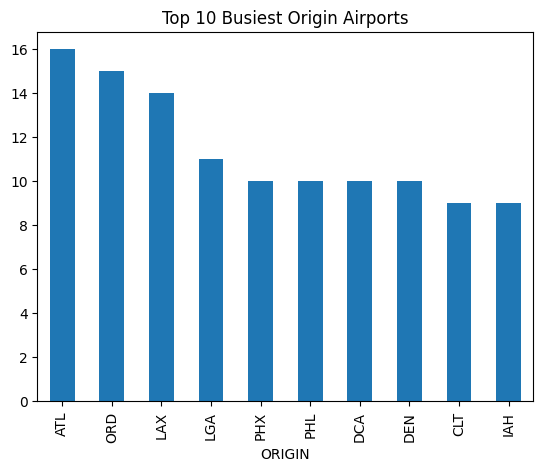

In [24]:
# Top Origin Airports
df['ORIGIN'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Busiest Origin Airports")
plt.show()

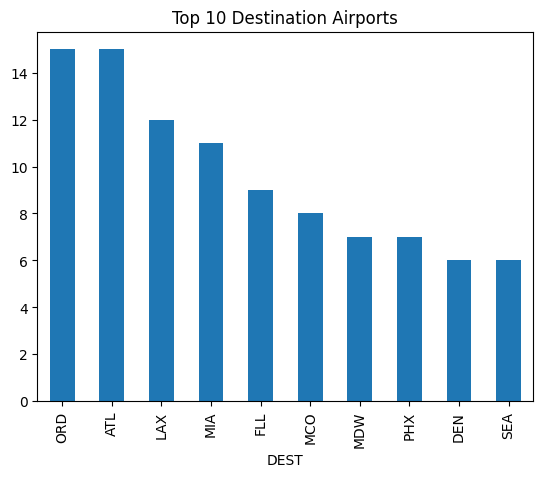

In [25]:
# DESTINATION ANALYSIS
df['DEST'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Destination Airports")
plt.show()

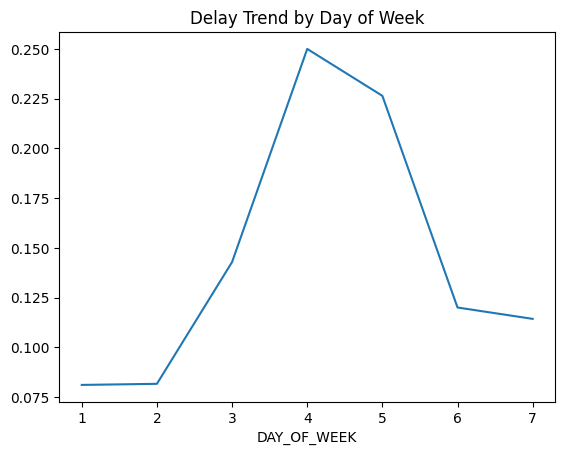

In [26]:
# DAY OF WEEK IMPACT ⭐
df.groupby('DAY_OF_WEEK')['DEP_DEL15'].mean().plot(kind='line')

plt.title("Delay Trend by Day of Week")
plt.show()

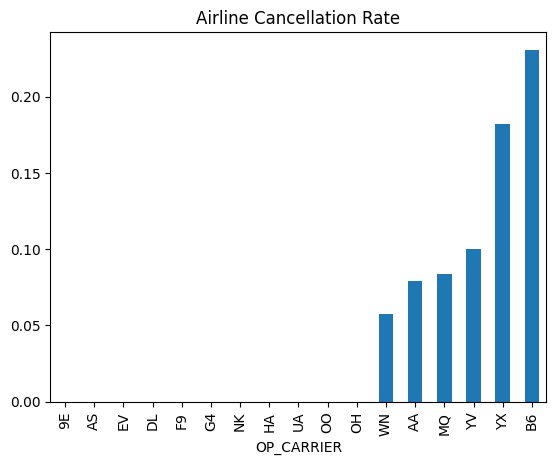

In [35]:
# AIRLINE vs CANCELLATION
df.groupby('OP_CARRIER')['CANCELLED_NUM'].mean().sort_values().plot(kind='bar')

plt.title("Airline Cancellation Rate")
plt.show()

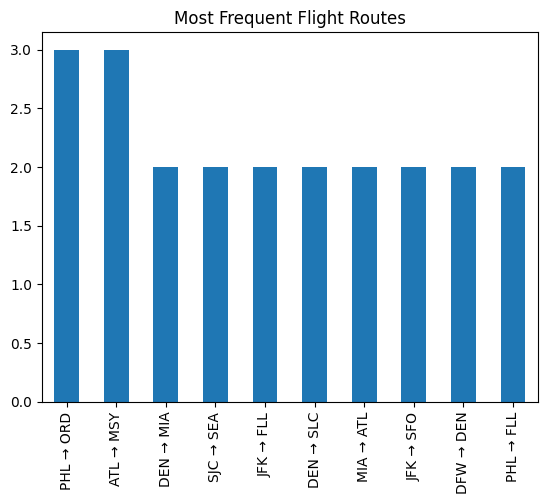

In [28]:
# ROUTE ANALYSIS
route = df['ORIGIN'] + " → " + df['DEST']

route.value_counts().head(10).plot(kind='bar')

plt.title("Most Frequent Flight Routes")
plt.show()

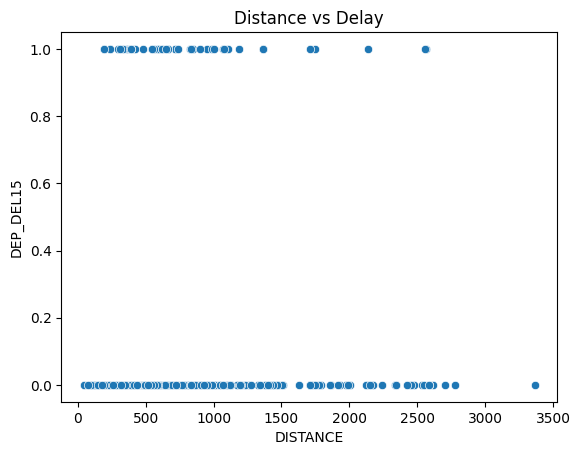

In [29]:
# DELAY VS DISTANCE
import seaborn as sns

sns.scatterplot(x='DISTANCE', y='DEP_DEL15', data=df)

plt.title("Distance vs Delay")
plt.show()

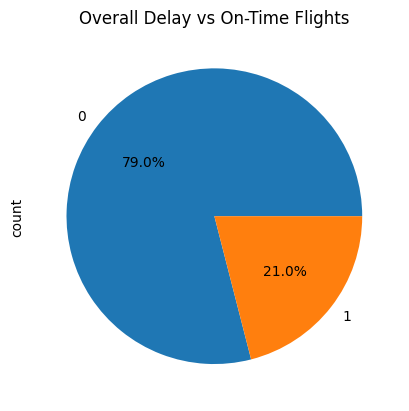

In [31]:
# OVERALL DELAY FLAG
df['Any_Delay'] = ((df['DEP_DEL15'] == 1) | (df['ARR_DEL15'] == 1)).astype(int)

df['Any_Delay'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Overall Delay vs On-Time Flights")
plt.show()

In [36]:
# Total Flights
total_flights = len(df)
print("Total Flights:", total_flights)

Total Flights: 300


In [37]:
# Total Delays
total_delays = df['DEP_DEL15'].sum() + df['ARR_DEL15'].sum()
print("Total Delays:", total_delays)

Total Delays: 98.0


In [39]:
# Delay Rate %
delay_rate = df['DEP_DEL15'].mean() * 100
print("Departure Delay Rate %:", round(delay_rate,2))

Departure Delay Rate %: 15.33


In [41]:
# IRLINE PERFORMANCE SCORE
airline_score = df.groupby('OP_CARRIER')['DEP_DEL15'].mean().sort_values()

print(airline_score)

OP_CARRIER
G4    0.000000
HA    0.000000
AS    0.045455
MQ    0.083333
YX    0.090909
YV    0.100000
OO    0.103448
AA    0.105263
B6    0.153846
UA    0.160000
WN    0.192308
NK    0.200000
F9    0.200000
DL    0.210526
EV    0.222222
9E    0.250000
OH    0.307692
Name: DEP_DEL15, dtype: float64


In [42]:
# DELAY RATE CALCULATION
airline_performance = df.groupby('OP_CARRIER')['DEP_DEL15'].mean().sort_values()

print(airline_performance)

OP_CARRIER
G4    0.000000
HA    0.000000
AS    0.045455
MQ    0.083333
YX    0.090909
YV    0.100000
OO    0.103448
AA    0.105263
B6    0.153846
UA    0.160000
WN    0.192308
NK    0.200000
F9    0.200000
DL    0.210526
EV    0.222222
9E    0.250000
OH    0.307692
Name: DEP_DEL15, dtype: float64


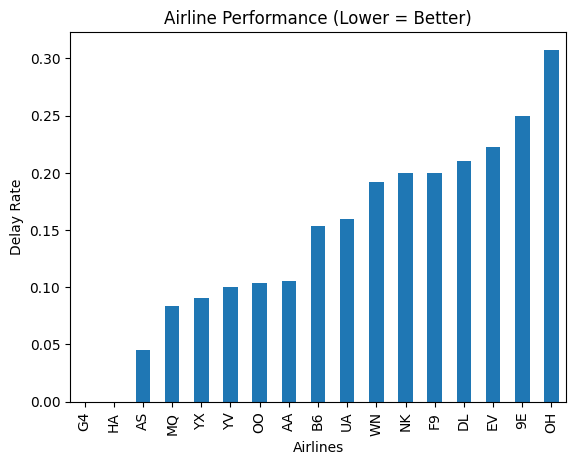

In [43]:
# VISUALIZATION
import matplotlib.pyplot as plt

airline_performance.plot(kind='bar')

plt.title("Airline Performance (Lower = Better)")
plt.ylabel("Delay Rate")
plt.xlabel("Airlines")
plt.show()

In [44]:
# BEST & WORST AIRLINE FIND
best_airline = airline_performance.idxmin()
worst_airline = airline_performance.idxmax()

print("Best Airline:", best_airline)
print("Worst Airline:", worst_airline)

Best Airline: G4
Worst Airline: OH


In [45]:
# CLEAN BUSINESS VERSION
result = pd.DataFrame({
    'Airline': airline_performance.index,
    'Delay_Rate': airline_performance.values
})

print(result)

   Airline  Delay_Rate
0       G4    0.000000
1       HA    0.000000
2       AS    0.045455
3       MQ    0.083333
4       YX    0.090909
5       YV    0.100000
6       OO    0.103448
7       AA    0.105263
8       B6    0.153846
9       UA    0.160000
10      WN    0.192308
11      NK    0.200000
12      F9    0.200000
13      DL    0.210526
14      EV    0.222222
15      9E    0.250000
16      OH    0.307692


In [46]:
# CLEAN BUSINESS VERSION 
result = pd.DataFrame({
    'Airline': airline_performance.index,
    'Delay_Rate': airline_performance.values
})

print(result)

   Airline  Delay_Rate
0       G4    0.000000
1       HA    0.000000
2       AS    0.045455
3       MQ    0.083333
4       YX    0.090909
5       YV    0.100000
6       OO    0.103448
7       AA    0.105263
8       B6    0.153846
9       UA    0.160000
10      WN    0.192308
11      NK    0.200000
12      F9    0.200000
13      DL    0.210526
14      EV    0.222222
15      9E    0.250000
16      OH    0.307692


In [52]:
top_origins = df['ORIGIN'].value_counts().head(10)
print(top_origins)

ORIGIN
ATL    16
ORD    15
LAX    14
LGA    11
PHX    10
PHL    10
DCA    10
DEN    10
CLT     9
IAH     9
Name: count, dtype: int64


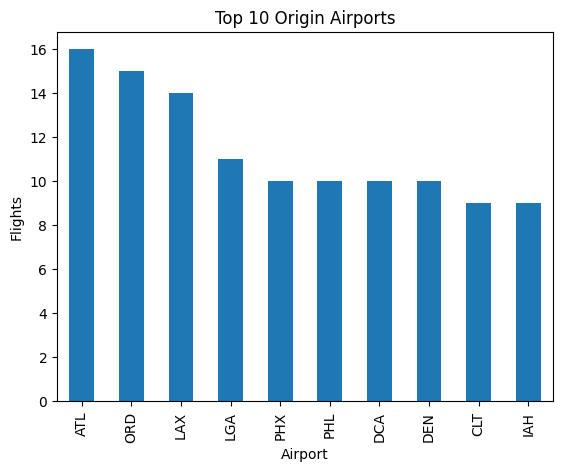

In [53]:
import matplotlib.pyplot as plt

top_origins.plot(kind='bar')

plt.title("Top 10 Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Flights")
plt.show()

In [54]:
# TOP DESTINATION AIRPORTS
top_dest = df['DEST'].value_counts().head(10)

print(top_dest)

DEST
ORD    15
ATL    15
LAX    12
MIA    11
FLL     9
MCO     8
MDW     7
PHX     7
DEN     6
SEA     6
Name: count, dtype: int64


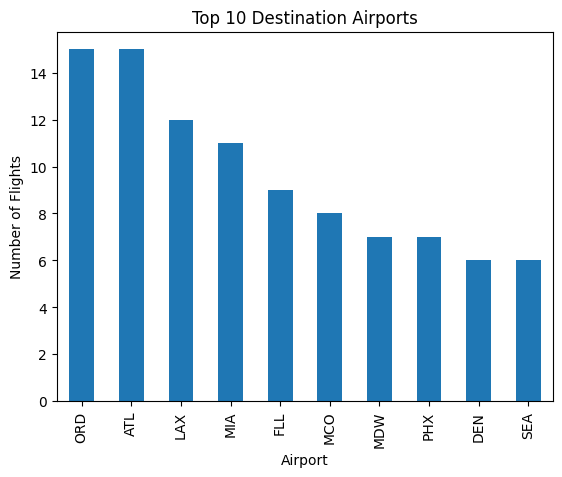

In [55]:
# VISUAL
top_dest.plot(kind='bar')

plt.title("Top 10 Destination Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.show()

In [57]:
# AIRPORT DELAY IMPACT
airport_delay = df.groupby('ORIGIN')['DEP_DEL15'].mean().sort_values(ascending=False).head(10)

print(airport_delay)

ORIGIN
BNA    1.000000
OKC    1.000000
ONT    1.000000
LGB    1.000000
PVD    1.000000
JAN    1.000000
BHM    0.500000
OAK    0.500000
SAT    0.500000
MCO    0.444444
Name: DEP_DEL15, dtype: float64


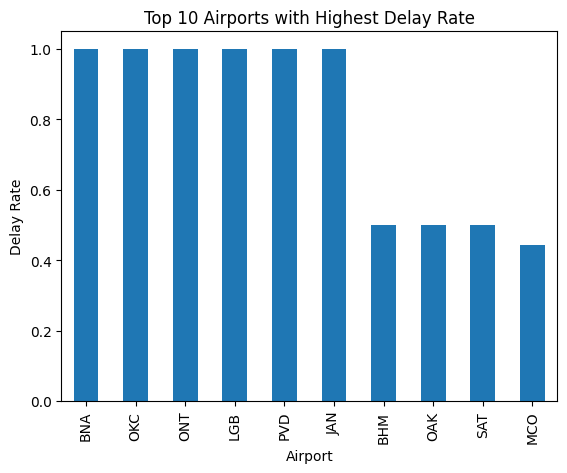

In [58]:
# VISUAL
airport_delay.plot(kind='bar')

plt.title("Top 10 Airports with Highest Delay Rate")
plt.xlabel("Airport")
plt.ylabel("Delay Rate")
plt.show()

In [59]:
# COMBINED VIEW
airport_summary = pd.DataFrame({
    'Flights': df['ORIGIN'].value_counts(),
    'Delay_Rate': df.groupby('ORIGIN')['DEP_DEL15'].mean()
}).dropna()

print(airport_summary.head())

        Flights  Delay_Rate
ORIGIN                     
ACY           1         0.0
AEX           1         0.0
ALB           1         0.0
AMA           1         0.0
ASE           1         0.0


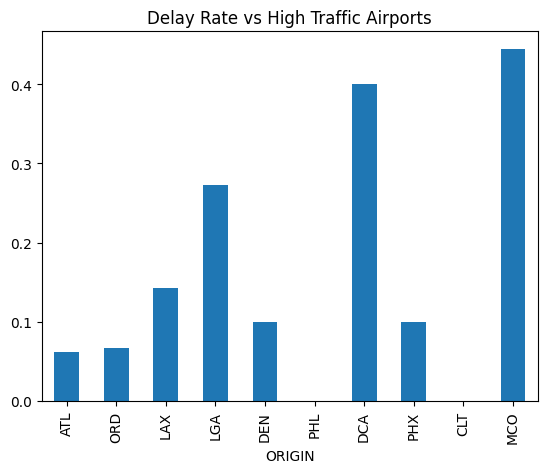

In [60]:
# OPTIONAL VISUAL
airport_summary.sort_values('Flights', ascending=False).head(10)['Delay_Rate'].plot(kind='bar')

plt.title("Delay Rate vs High Traffic Airports")
plt.show()